# A notebook to train a UNET to perfom a PIXEL-based classification of kontas_2017 dataset

## Import Usepackages

In [1]:
import torch
import gc

# Force clear everything
torch.cuda.empty_cache()
gc.collect()


import numpy as np
import seaborn as sns
import random
import cv2
import mlflow
import joblib
from tqdm import tqdm
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
import torchvision.transforms.functional as TF

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, jaccard_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from mpl_toolkits.axes_grid1 import make_axes_locatable



## Pre-defined Functions

In [2]:
# Resizing the dataset images
class SegDataset(Dataset):
    def __init__(self, images, masks, img_size=(256, 256)):
        self.images   = images
        self.masks    = masks
        self.img_size = img_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img  = torch.from_numpy(self.images[idx]).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(self.masks[idx]).long()
        img  = TF.resize(img, list(self.img_size),
                         interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask.unsqueeze(0), list(self.img_size),
                         interpolation=TF.InterpolationMode.NEAREST).squeeze(0)
        return img, mask

In [3]:
# Unet Architecture
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        
        # Encoder
        self.downs = nn.ModuleList()
        for feature in features:
            self.downs.append(self.double_conv(in_channels, feature))
            in_channels = feature
        
        # Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bottleneck
        self.bottleneck = self.double_conv(features[-1], features[-1]*2)
        
        # Decoder
        self.ups = nn.ModuleList()
        self.up_convs = nn.ModuleList()
        reversed_features = list(reversed(features))
        for idx, feature in enumerate(reversed_features):
            if idx == 0:
                up_in_channels = features[-1]*2
            else:
                up_in_channels = feature*2
            self.ups.append(nn.ConvTranspose2d(up_in_channels, feature, kernel_size=2, stride=2))
            self.up_convs.append(self.double_conv(feature*2, feature))
        
        # Output layer -> 3 Klassen
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
    
    def forward(self, x):
        skip_connections = []
        
        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder
        skip_connections = skip_connections[::-1]
        for idx in range(len(self.ups)):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx]
            
            # Falls Dimensionen nicht passen
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])
            
            x = torch.cat((skip_connection, x), dim=1)
            x = self.up_convs[idx](x)
        
        return self.final_conv(x)  # Keine Sigmoid! -> CrossEntropyLoss erwartet Logits
    
    def double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

In [4]:
def show_predicted_images(idxExample,imgExample,masks,pred_mask):

    cmap = ListedColormap(['black', 'blue', 'white'])

    fig, axes = plt.subplots(2, 3, figsize=(7, 5))

    axes[0,0].imshow(imgExample.squeeze())
    axes[0,0].set_title(f'Original Image {idxExample}')
    axes[0,0].axis('off')

    axes[0,1].imshow(masks[idxExample:idxExample+1].squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[0,1].set_title(f'Original Mask')
    axes[0,1].axis('off')

    axes[0,2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=2)
    axes[0,2].set_title(f'Predicted Mask')
    axes[0,2].axis('off')



    diff = masks[idxExample].squeeze().astype(int) - pred_mask.squeeze().astype(int)

    im  = axes[1,2].imshow(diff, cmap='RdBu', vmin=-2, vmax=2)
    axes[1,2].set_title('Mask Differences')
    axes[1,2].axis('off')


    axes[1,0].axis('off')  # just turn it off — leaves it blank
    axes[1,1].axis('off')  # just turn it off — leaves it blank

    # Attach colorbar to axes[3] without stealing space from other plots
    divider = make_axes_locatable(axes[1,2])
    cax     = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax, ticks=[-2, -1, 0, 1, 2])


    unique, counts = np.unique(diff, return_counts=True)
    total = diff.size

    print(f"{'Value':>8} {'Count':>10} {'Percentage':>12}")
    print("-" * 32)
    for val, cnt in zip(unique, counts):
        print(f"{val:>8} {cnt:>10,} {cnt/total:>11.1%}")


## Load Data

The data were generated with the script: 01_kontas2017_dataPreparation. Therefore, they only have to be loaded here!

In [5]:
# Load in another notebook:
data   = np.load("dataset.npz") #np.savez("dataset.npz", images=images, masks=masks)
images = data["images"].copy()  # force full load
masks  = data["masks"].copy()
data.close()
del data

print("Number of images: ",len(images))
print("Number of masks: ",len(masks))
print(f" - Size of an image: {images[0].shape}")
print(" - Size of a mask: ",masks[0].shape)

Number of images:  1540
Number of masks:  1540
 - Size of an image: (512, 512, 3)
 - Size of a mask:  (512, 512)


## Train the Model

In [6]:
# Dataloader
batch_size    = 6
img_size      = (256, 256) # Resize is done due to memory limitations

full_dataset = SegDataset(images, masks, img_size=img_size)
train_size   = int(0.7 * len(full_dataset))
val_size     = int(0.2 * len(full_dataset))
test_size    = len(full_dataset) - train_size - val_size

train_set, val_set, test_set = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
device        = "cuda" if torch.cuda.is_available() else "cpu"
pin = device == "cuda"
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=pin)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=pin)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=pin)

In [7]:
# Hyperparameters
num_epochs    = 70 #50
learning_rate = 1e-4

# Model
unet      = UNet(in_channels=3, out_channels=3).to(device)


# Count class frequencies across all masks
counts = Counter()
for m in masks:
    counts.update(m.flatten().tolist())

total = sum(counts.values())
num_classes = 3

# Inverse frequency weighting
weights = torch.tensor([
    total / (num_classes * counts[i]) for i in range(num_classes)
], dtype=torch.float32).to(device)

print(f"Class weights: {weights}")  # cloudy class should get higher weight

criterion = nn.CrossEntropyLoss(weight=weights)

#criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.Adam(unet.parameters(), lr=learning_rate)
optimizer = torch.optim.Adam(unet.parameters(), lr=learning_rate, weight_decay=1e-4)
scaler    = GradScaler()   # for mixed precision

train_losses, val_losses = [], []

# Train-loop
for epoch in range(num_epochs):
    gc.collect()
    torch.cuda.empty_cache()

    unet.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")


    for imgs, masks_act in pbar:
        imgs, masks_act = imgs.to(device), masks_act.to(device)
        optimizer.zero_grad(set_to_none=True)  # frees memory vs zero_grad()

        with autocast():
            preds = unet(imgs)
            loss  = criterion(preds, masks_act)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix({"train_loss": running_loss / (pbar.n+1)})

    train_losses.append(running_loss / len(train_loader))

    # Validation
    unet.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for imgs, masks_act in val_loader:
            imgs, masks_act = imgs.to(device), masks_act.to(device)
            with autocast():
                preds = unet(imgs)
                val_running_loss += criterion(preds, masks_act).item()

    val_losses.append(val_running_loss / len(val_loader))

    gc.collect()
    torch.cuda.empty_cache()

    print(f"Epoch {epoch+1}/{num_epochs} — "
          f"Train: {train_losses[-1]:.4f}  Val: {val_losses[-1]:.4f}")

Class weights: tensor([1.4856, 0.7296, 1.0457], device='cuda:0')


Epoch 1/70: 100%|██████████| 180/180 [00:32<00:00,  5.51it/s, train_loss=0.345]


Epoch 1/70 — Train: 0.3451  Val: 0.2303


Epoch 2/70: 100%|██████████| 180/180 [00:28<00:00,  6.37it/s, train_loss=0.247]


Epoch 2/70 — Train: 0.2471  Val: 0.2044


...

Epoch 68/70 — Train: 0.0871  Val: 0.1083


Epoch 69/70: 100%|██████████| 180/180 [00:14<00:00, 12.79it/s, train_loss=0.0842]


Epoch 69/70 — Train: 0.0842  Val: 0.0995


Epoch 70/70: 100%|██████████| 180/180 [00:14<00:00, 12.80it/s, train_loss=0.0889]


Epoch 70/70 — Train: 0.0889  Val: 0.1009


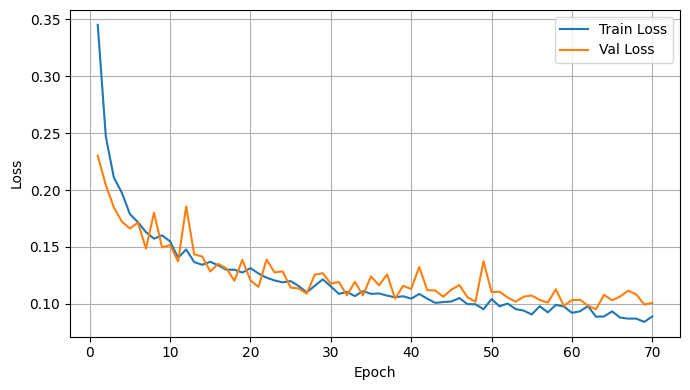

In [8]:
fig, axes = plt.subplots(figsize=(7, 4))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

## Image resp. Mask Reproduction

Shape before argmax: torch.Size([1, 3, 512, 512])
Min/Max values: -11.363, 10.551
Is it logits? (should have negative values): True


[-11.36328  -11.336939 -11.299102 ...  10.25806   10.259534  10.551345]
True: Zeros: 58594, Ones: 45318, Twos: 158232
Prediction: Zeros: 0, Ones: 0, Twos: 0
   Value      Count   Percentage
--------------------------------
      -2        223        0.1%
      -1     11,469        4.4%
       0    246,437       94.0%
       1      3,784        1.4%
       2        231        0.1%
Shape before argmax: torch.Size([1, 3, 512, 512])
Min/Max values: -9.285, 11.476
Is it logits? (should have negative values): True
[-9.284888 -9.281018 -9.270119 ... 11.442278 11.450371 11.475632]
True: Zeros: 58955, Ones: 45, Twos: 203144
Prediction: Zeros: 0, Ones: 0, Twos: 0
   Value      Count   Percentage
--------------------------------
      -2      1,748        0.7%
      -1        354        0.1%
       0    260,031       99.2%
       2         11        0.0%
Shape before argmax: torch.Size([1, 3, 512, 512])
Min/Max values: -10.287, 10.087
Is it logits? (should have negative values): True
[-10.286881 

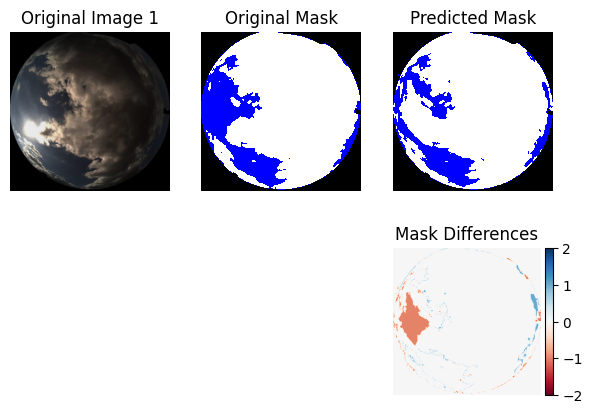

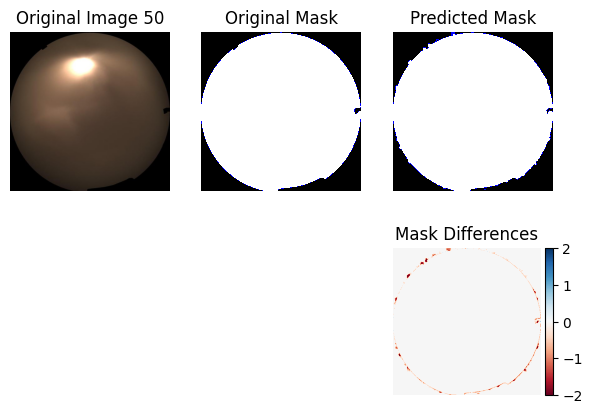

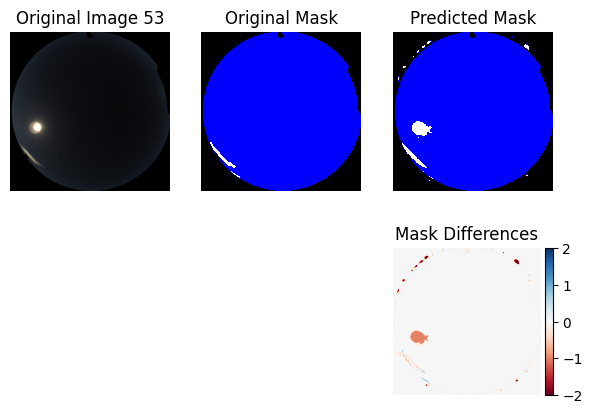

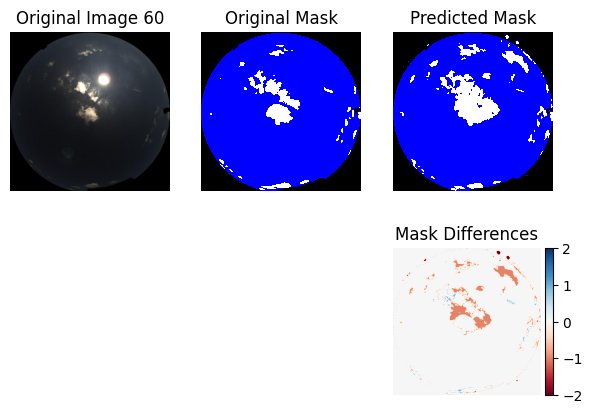

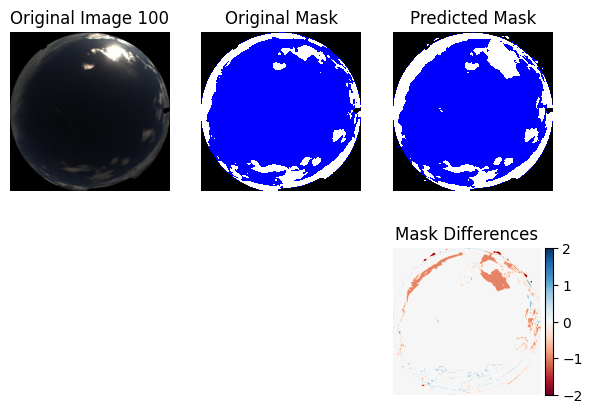

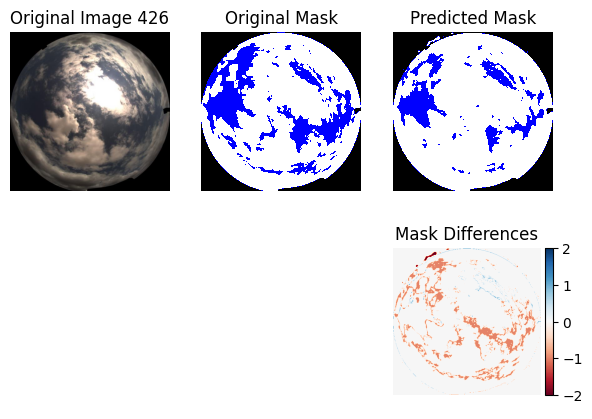

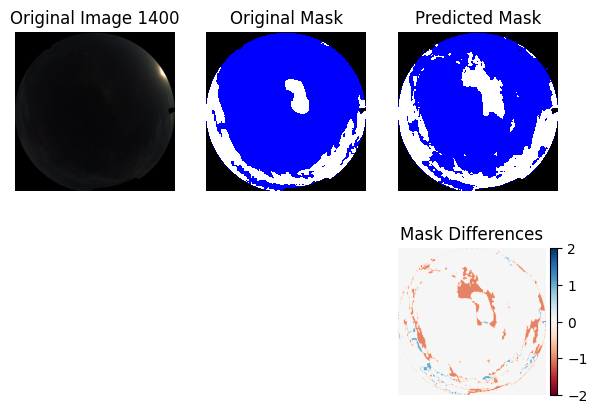

In [9]:
for idxExample in [1,50,53,60,100,426, 1400]:


    imgExample = images[idxExample:idxExample+1].squeeze(0)
    test_mask = masks[idxExample]    # (H, W) oder (H, W, 1)


    # 1. zu Tensor
    test_img_tensor = torch.from_numpy(imgExample).permute(2,0,1).float()/ 255.0   # (C,H,W)

    # 2. Batch-Dimension hinzufügen
    test_img_tensor = test_img_tensor.unsqueeze(0).to(device)  # (1,C,H,W)

    # 3. Vorhersage
    unet.eval()
    with torch.no_grad():
        pred_mask = unet(test_img_tensor)          # (1,1,H,W)
        #pred_mask = (pred_mask.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

    print(f"Shape before argmax: {pred_mask.shape}")
    print(f"Min/Max values: {pred_mask.min():.3f}, {pred_mask.max():.3f}")
    print(f"Is it logits? (should have negative values): {(pred_mask < 0).any()}")

    # logits -> argmax über die Kanal-Dimension
    # pred_mask = torch.argmax(pred_mask, dim=0)  # Shape: (H,W)
    pred_mask = pred_mask.cpu().numpy()

    print(np.unique(pred_mask))


    num_zeros = np.sum(test_mask == 0)
    num_ones  = np.sum(test_mask == 1)
    num_twos  = np.sum(test_mask == 2)

    num_zerosP = np.sum(pred_mask == 0)
    num_onesP  = np.sum(pred_mask == 1)
    num_twosP  = np.sum(pred_mask == 2)



    print(f"True: Zeros: {num_zeros}, Ones: {num_ones}, Twos: {num_twos}")
    print(f"Prediction: Zeros: {num_zerosP}, Ones: {num_onesP}, Twos: {num_twosP}")


    unet.eval()
    with torch.no_grad():
        # Test image muss die Form (1,3,H,W) haben
        pred_logits = unet(test_img_tensor)         # Shape: (1,3,H,W)
        
        # Klassenvorhersage: argmax über Kanal-Dimension
        pred_mask = torch.argmax(pred_logits, dim=1)  # Shape: (1,H,W)
        
        # Optional: nur 2D für plotting
        pred_mask = pred_mask.squeeze(0).cpu().numpy()  # Shape: (H,W)


    show_predicted_images(idxExample,imgExample,masks,pred_mask)

Text(0.5, 25.722222222222214, 'Predicted Class')

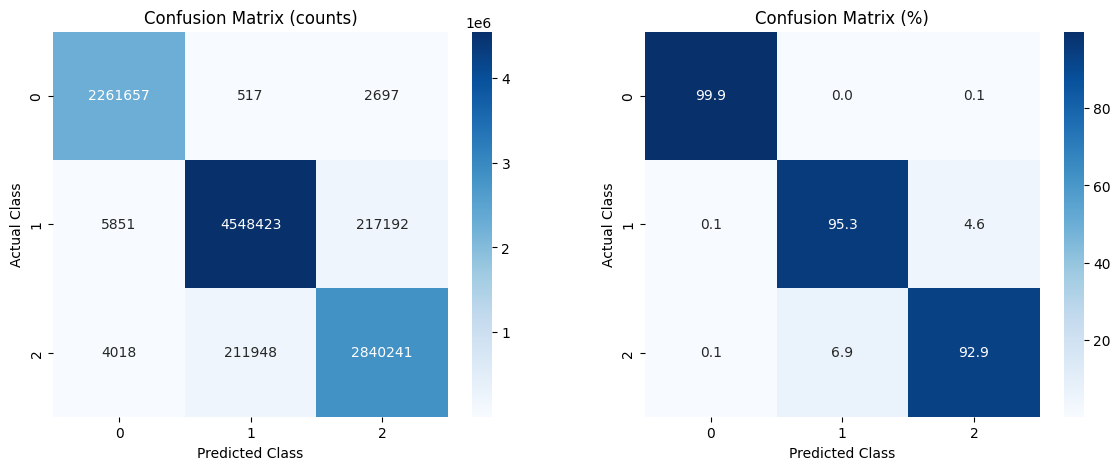

In [10]:
# Collect all predictions and targets
all_preds  = []
all_labels = []

unet.eval()
with torch.no_grad():
    for imgs, masks_act in test_loader:
        imgs, masks_act = imgs.to(device), masks_act.to(device)
        preds     = unet(imgs)
        pred_mask = torch.argmax(preds, dim=1)  # (N, H, W)

        all_preds.append(pred_mask.cpu().numpy().flatten())
        all_labels.append(masks_act.cpu().numpy().flatten())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Confusion Matrix
cm     = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row-normalize %

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[0,1,2],
            yticklabels=[0,1,2])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('Actual Class')
axes[0].set_xlabel('Predicted Class')

# Percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=[0,1,2],
            yticklabels=[0,1,2])
axes[1].set_title('Confusion Matrix (%)')
axes[1].set_ylabel('Actual Class')
axes[1].set_xlabel('Predicted Class')

## Apply Random Forest on SwissOGS Images

In [11]:
# Define image and mask files
basePath = Path(r'SwissOGS')

# Append last_dir
image_path = basePath


image_paths = sorted(Path(image_path).glob("*.jpg"))

In [12]:
# Get data

imagesOGS = []

for idx, img_path in enumerate(image_paths):
    image = Image.open(img_path).convert("RGB")
    image.load()
    imagesOGS.append(image)

# Data set
imagesOGS = [np.array(img) for img in imagesOGS]

print("Number of images: ",len(imagesOGS))

print(" - Size of a image: ",imagesOGS[0].shape)

Number of images:  6
 - Size of a image:  (2822, 3044, 3)


In [13]:
def show_predicted_imagesOGS(idxExample,imgExample,pred_mask):

    cmap = ListedColormap(['black', 'blue', 'white'])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(np.array(imgExample))
    axes[0].set_title(f'Original Image {idxExample}')
    axes[0].axis('off')

    axes[1].imshow(pred_mask.squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[1].set_title(f'Predicted Mask')
    axes[1].axis('off')



Shape before argmax: torch.Size([1, 3, 2822, 3044])
Min/Max values: -17.335, 17.976
Is it logits? (should have negative values): True
Shape before argmax: torch.Size([1, 3, 2822, 3044])
Min/Max values: -17.341, 17.977
Is it logits? (should have negative values): True
Shape before argmax: torch.Size([1, 3, 2822, 3044])
Min/Max values: -16.595, 15.288
Is it logits? (should have negative values): True
Shape before argmax: torch.Size([1, 3, 2822, 3044])
Min/Max values: -16.595, 16.566
Is it logits? (should have negative values): True
Shape before argmax: torch.Size([1, 3, 2822, 3044])
Min/Max values: -17.151, 15.288
Is it logits? (should have negative values): True
Shape before argmax: torch.Size([1, 3, 2822, 3044])
Min/Max values: -17.215, 15.288
Is it logits? (should have negative values): True


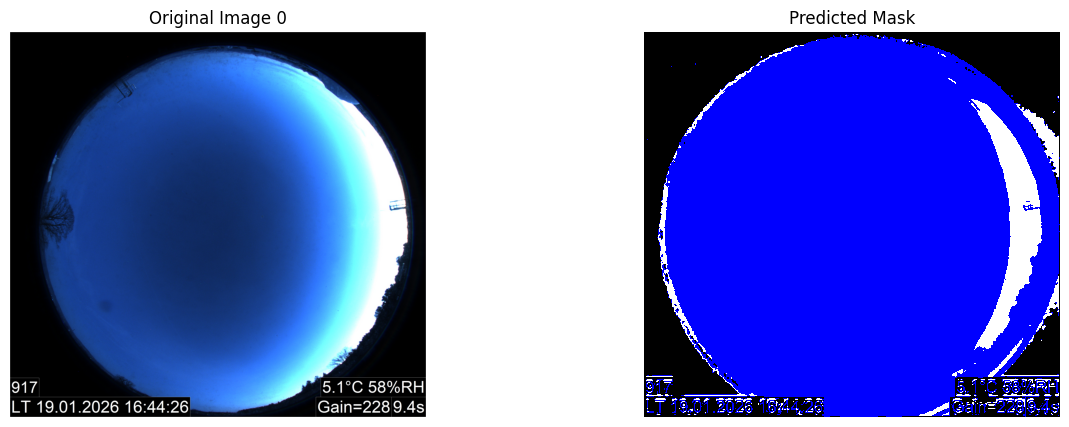

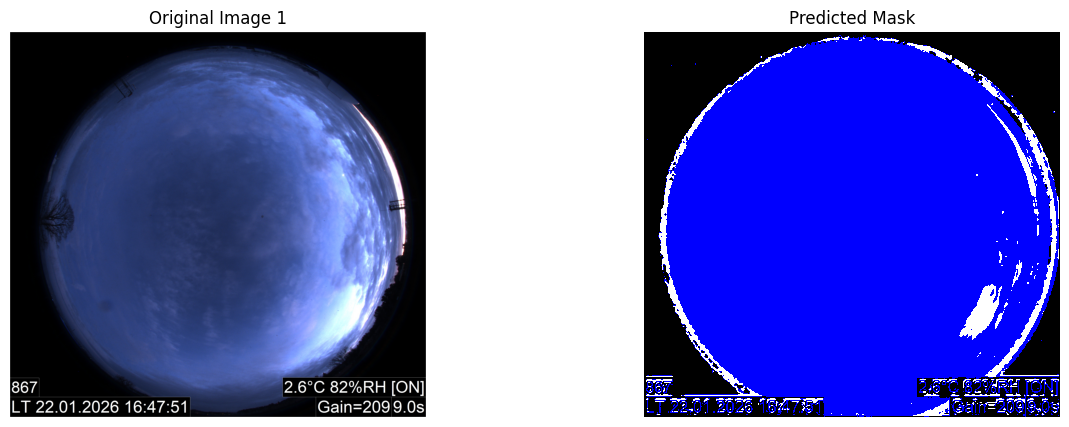

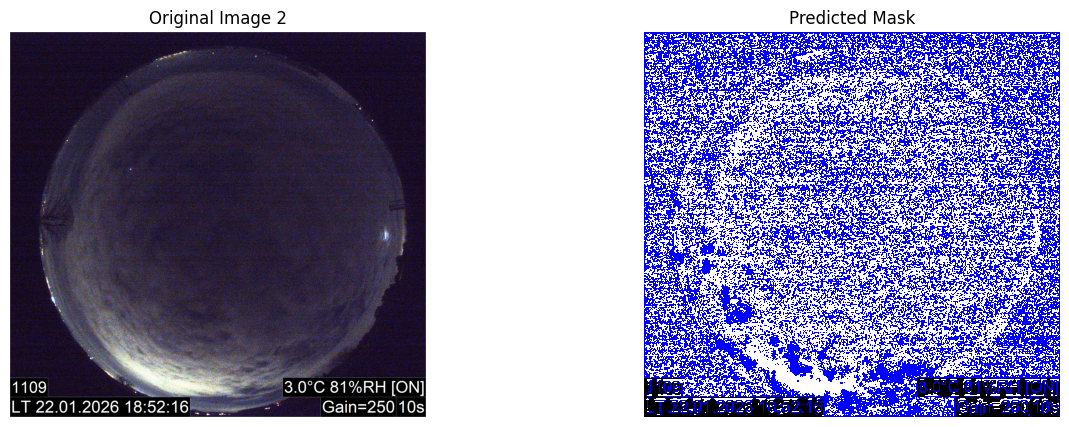

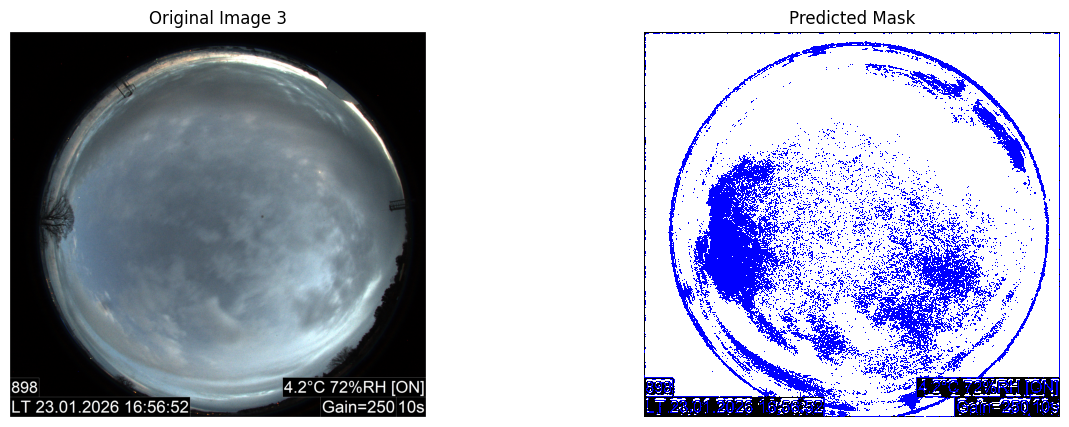

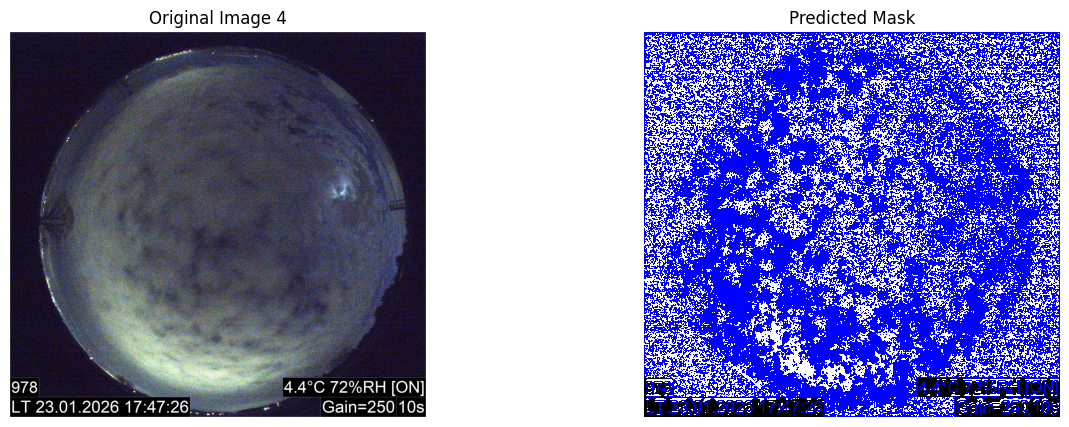

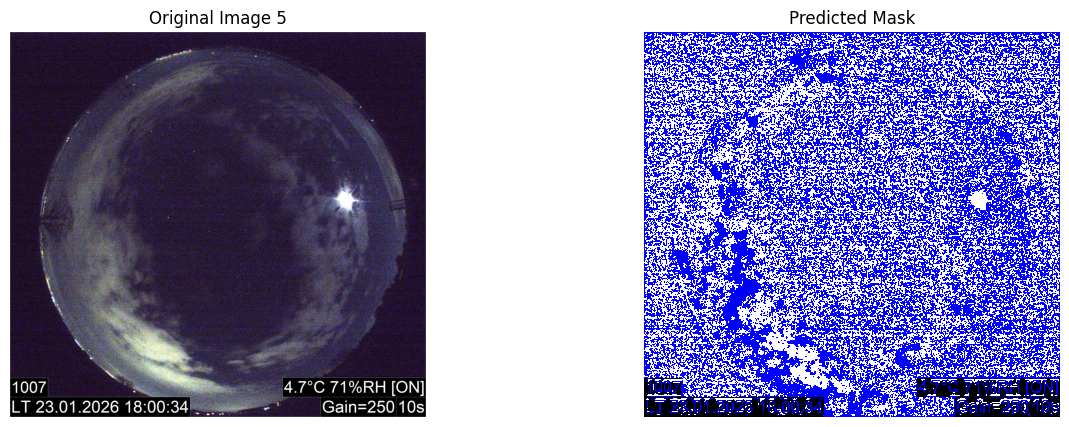

In [16]:
for idxExample in range(len(imagesOGS)):


    imgExample = imagesOGS[idxExample]

    # 1. zu Tensor
    test_img_tensor = torch.from_numpy(imgExample).permute(2,0,1).float()/ 255.0   # (C,H,W)

    # 2. Batch-Dimension hinzufügen
    test_img_tensor = test_img_tensor.unsqueeze(0).to(device)  # (1,C,H,W)

    # 3. Vorhersage
    unet.eval()
    with torch.no_grad():
        pred_mask = unet(test_img_tensor)          # (1,1,H,W)

    print(f"Shape before argmax: {pred_mask.shape}")
    print(f"Min/Max values: {pred_mask.min():.3f}, {pred_mask.max():.3f}")
    print(f"Is it logits? (should have negative values): {(pred_mask < 0).any()}")

    # logits -> argmax über die Kanal-Dimension
    pred_mask = pred_mask.cpu().numpy()

    unet.eval()
    with torch.no_grad():
        # Test image muss die Form (1,3,H,W) haben
        pred_logits = unet(test_img_tensor)         # Shape: (1,3,H,W)
        
        # Klassenvorhersage: argmax über Kanal-Dimension
        pred_mask = torch.argmax(pred_logits, dim=1)  # Shape: (1,H,W)
        
        # Optional: nur 2D für plotting
        pred_mask = pred_mask.squeeze(0).cpu().numpy()  # Shape: (H,W)
    

    show_predicted_imagesOGS(idxExample,imgExample,pred_mask)